        [분포 시각화 및 통계량 분석]
DATA : c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv
Normal rows        : 19,999
Abnormal rows      : 600
RMS evaluable      : 428
RMS not evaluable  : 172
RMS detected       : 235
RMS missed         : 193


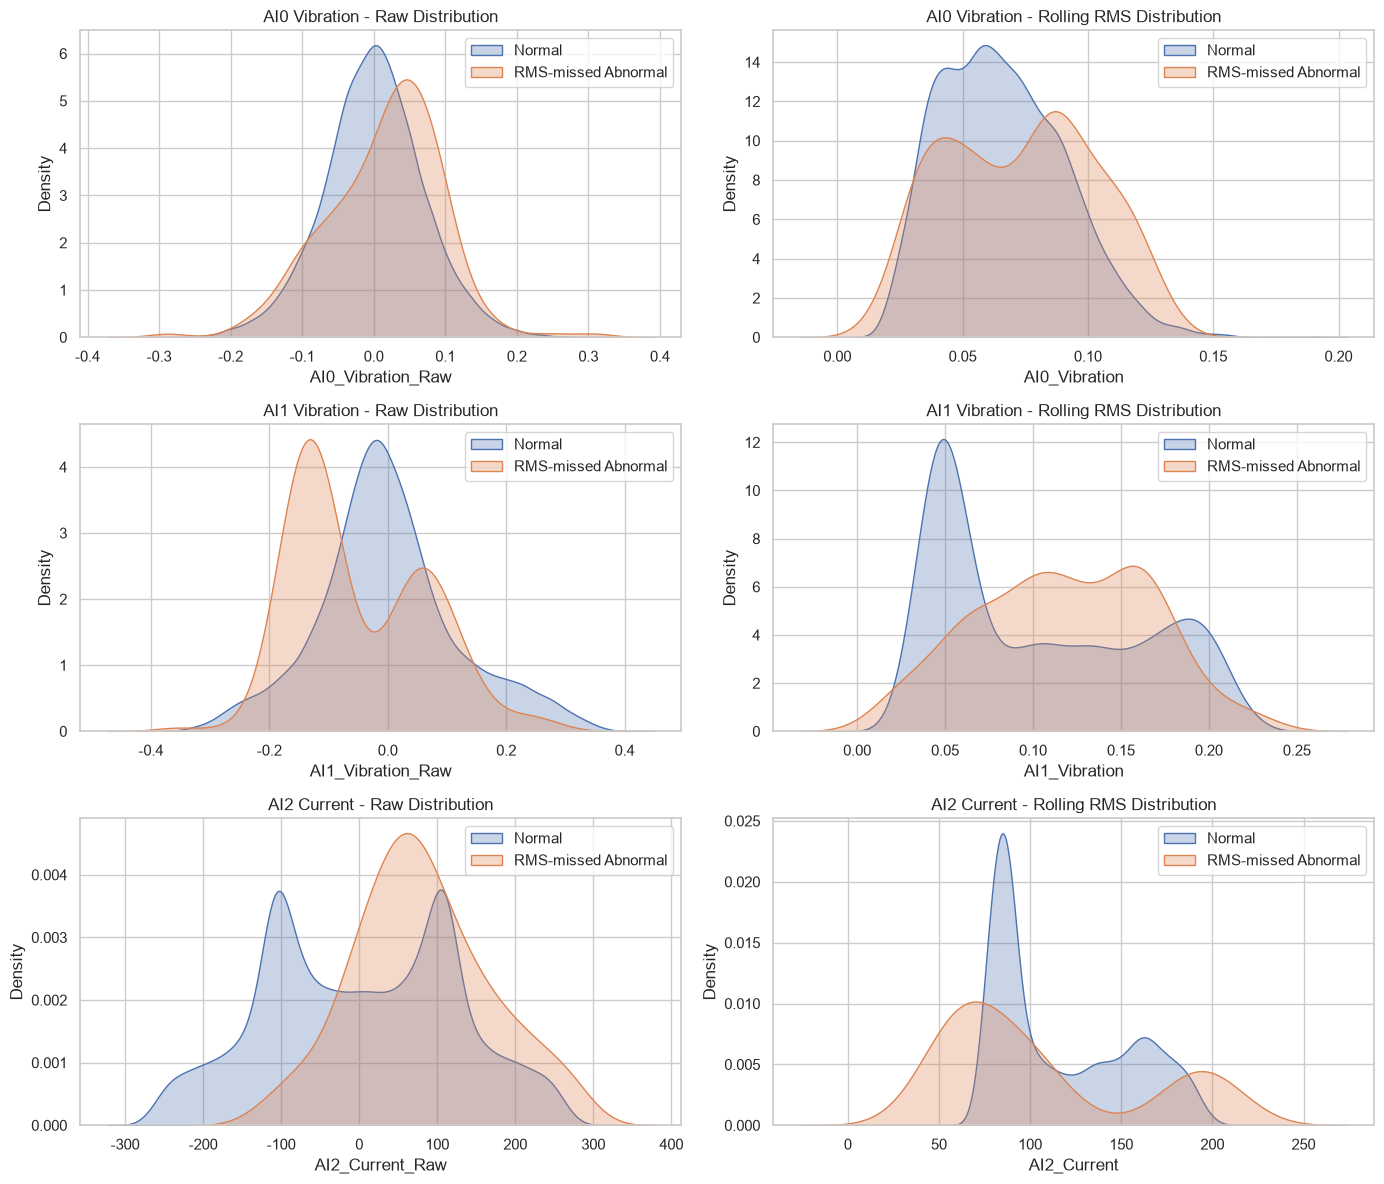

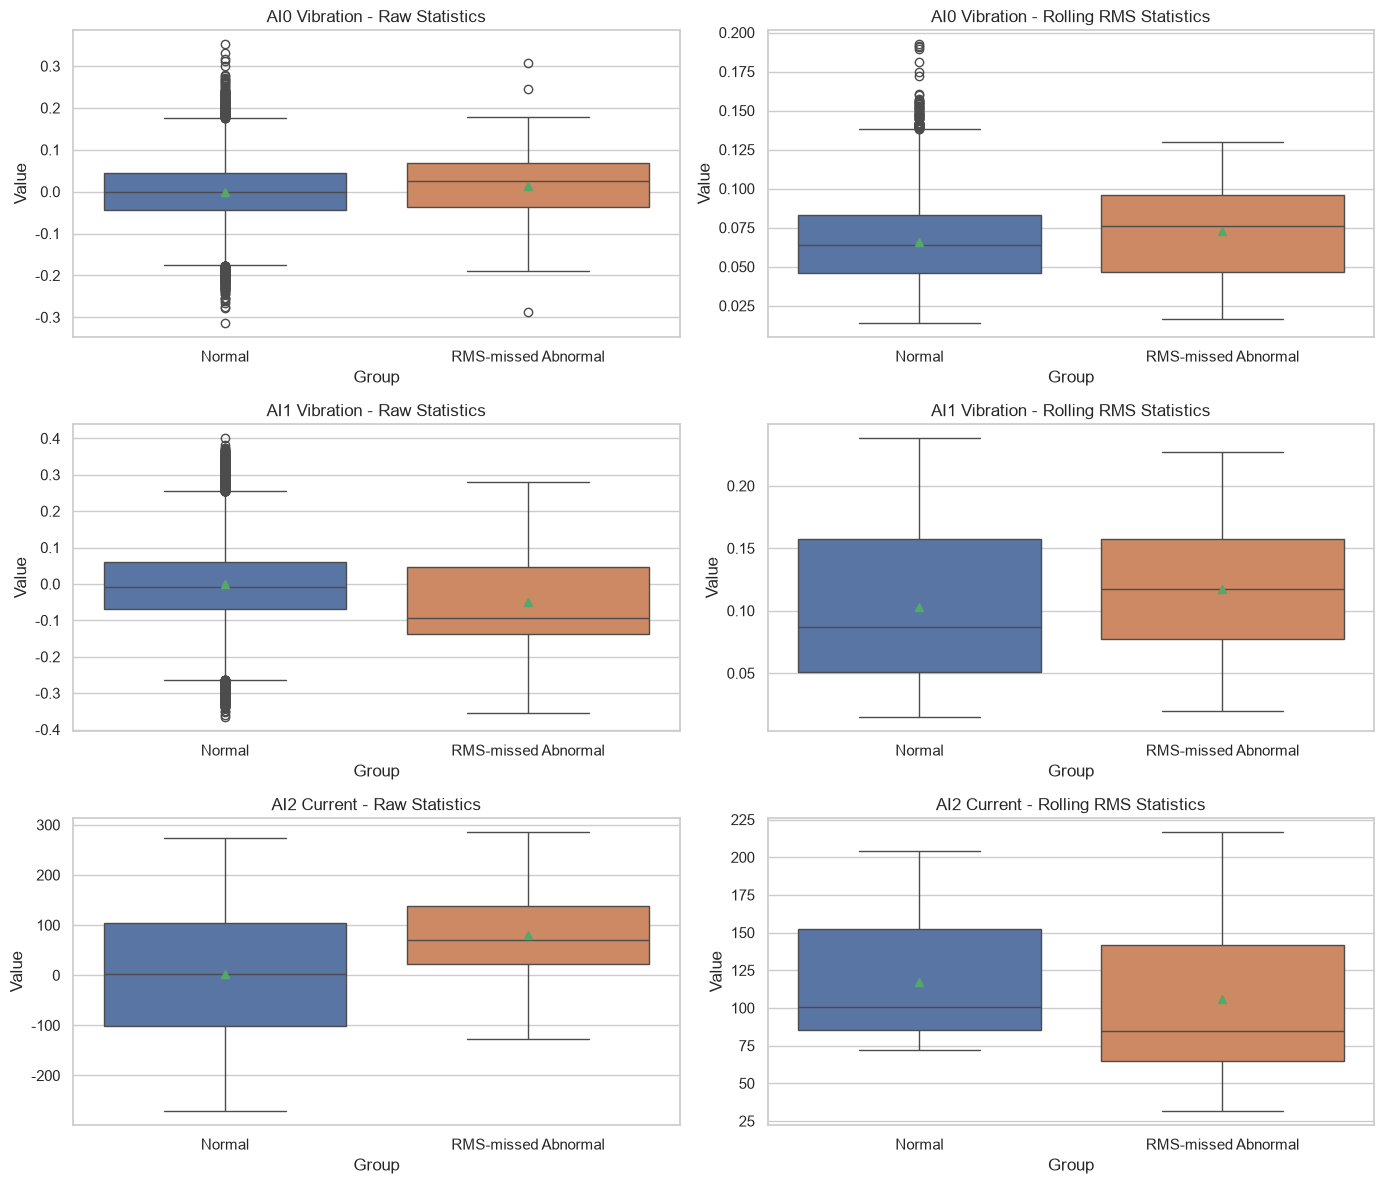


=== 채널별 주요 통계량 ===
      Channel               Group        Type     Mean      Std   Median        Q1       Q3    95% Q
AI0_Vibration              Normal         Raw  -0.0001   0.0706  -0.0002   -0.0442   0.0440   0.1170
AI0_Vibration              Normal Rolling_RMS   0.0658   0.0248   0.0637    0.0462   0.0830   0.1090
AI0_Vibration RMS-missed Abnormal         Raw   0.0144   0.0804   0.0264   -0.0367   0.0691   0.1169
AI0_Vibration RMS-missed Abnormal Rolling_RMS   0.0730   0.0294   0.0760    0.0467   0.0959   0.1198
AI1_Vibration              Normal         Raw  -0.0001   0.1189  -0.0093   -0.0693   0.0602   0.2281
AI1_Vibration              Normal Rolling_RMS   0.1032   0.0588   0.0868    0.0505   0.1574   0.2034
AI1_Vibration RMS-missed Abnormal         Raw  -0.0497   0.1140  -0.0942   -0.1389   0.0469   0.1324
AI1_Vibration RMS-missed Abnormal Rolling_RMS   0.1175   0.0492   0.1178    0.0769   0.1575   0.1891
  AI2_Current              Normal         Raw   1.4419 122.6661   1.847

In [1]:
# 공식 preprocessed_data.csv를 사용해 Normal과 Abnormal의 Raw / Rolling RMS 분포를 비교한다.
# 04_Preprocessing에서 확정된 segment_id를 그대로 사용하며 Timestamp 정렬·segment 재생성은 하지 않는다.
# 10-sample RMS는 완전한 window만 평가하고, 계산 불가능한 행은 not-evaluable로 유지한다.
# RMS-IQR에서 놓친 Abnormal을 분리해 분포·박스플롯·통계량을 비교한다.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

COLS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW = 10

def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists():
                return p
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
OUT = ROOT / "KAMP/05_EDA/05_EDA_Sensor4/results"
OUT.mkdir(parents=True, exist_ok=True)

print("==========================================")
print("        [분포 시각화 및 통계량 분석]")
print("==========================================")
print(f"DATA : {DATA_PATH}")

data = pd.read_csv(DATA_PATH)
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])

normal_proc = data[data["source"] == "normal"].copy()
outlier_proc = data[data["source"] == "abnormal"].copy()


# ------------------------------------------------------------
# Segment 내부 10-sample Rolling RMS
# ------------------------------------------------------------
def calculate_segment_rms(df):
    parts = []

    for seg_id, g in df.groupby("segment_id", sort=False):
        g = g.copy()
        rms = g[COLS].pow(2).rolling(WINDOW, min_periods=WINDOW).mean().pow(.5)

        for c in COLS:
            rms[f"{c}_Raw"] = g[c].to_numpy()

        rms["TimeStamp"] = g["TimeStamp"].to_numpy()
        rms["segment_id"] = seg_id
        rms["source_row"] = g["source_row"].to_numpy()

        parts.append(rms)

    return pd.concat(parts).sort_index()

normal_rms = calculate_segment_rms(normal_proc)
outlier_rms = calculate_segment_rms(outlier_proc)


# ------------------------------------------------------------
# Normal RMS-IQR Threshold
# ------------------------------------------------------------
thresholds = {}

for col in COLS:
    valid = normal_rms[col].dropna()
    q1, q3 = valid.quantile([.25, .75])
    iqr = q3 - q1
    thresholds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

normal_rms["RMS_evaluable"] = normal_rms[COLS].notna().all(axis=1)
outlier_rms["RMS_evaluable"] = outlier_rms[COLS].notna().all(axis=1)

detections = pd.DataFrame(False, index=outlier_rms.index, columns=COLS)

for col in COLS:
    lo, hi = thresholds[col]
    detections[col] = outlier_rms[col].notna() & (
        (outlier_rms[col] < lo) | (outlier_rms[col] > hi)
    )

outlier_rms["RMS_Detected"] = outlier_rms["RMS_evaluable"] & detections.any(axis=1)
outlier_rms["RMS_Missed"] = outlier_rms["RMS_evaluable"] & ~outlier_rms["RMS_Detected"]

undetected_rms = outlier_rms[outlier_rms["RMS_Missed"]].copy()

print(f"Normal rows        : {len(normal_rms):,}")
print(f"Abnormal rows      : {len(outlier_rms):,}")
print(f"RMS evaluable      : {outlier_rms['RMS_evaluable'].sum():,}")
print(f"RMS not evaluable  : {(~outlier_rms['RMS_evaluable']).sum():,}")
print(f"RMS detected       : {outlier_rms['RMS_Detected'].sum():,}")
print(f"RMS missed         : {outlier_rms['RMS_Missed'].sum():,}")


# ------------------------------------------------------------
# KDE : Normal vs RMS-missed Abnormal
# ------------------------------------------------------------
titles = ["AI0 Vibration", "AI1 Vibration", "AI2 Current"]
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(COLS):
    sns.kdeplot(normal_rms[f"{col}_Raw"].dropna(), label="Normal", ax=axes[i,0], fill=True, alpha=.3)
    sns.kdeplot(undetected_rms[f"{col}_Raw"].dropna(), label="RMS-missed Abnormal", ax=axes[i,0], fill=True, alpha=.3)
    axes[i,0].set_title(f"{titles[i]} - Raw Distribution")
    axes[i,0].legend()

    sns.kdeplot(normal_rms[col].dropna(), label="Normal", ax=axes[i,1], fill=True, alpha=.3)
    sns.kdeplot(undetected_rms[col].dropna(), label="RMS-missed Abnormal", ax=axes[i,1], fill=True, alpha=.3)
    axes[i,1].set_title(f"{titles[i]} - Rolling RMS Distribution")
    axes[i,1].legend()

plt.tight_layout()
plt.savefig(OUT / "distribution_comparison.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------
plot_rows = []

for col in COLS:
    for group, df in [("Normal", normal_rms), ("RMS-missed Abnormal", undetected_rms)]:
        for feature, s in [("Raw", df[f"{col}_Raw"]), ("Rolling_RMS", df[col])]:
            plot_rows.extend({
                "Channel": col, "Feature": feature,
                "Group": group, "Value": v
            } for v in s.dropna())

plot_df = pd.DataFrame(plot_rows)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(COLS):
    sub = plot_df[plot_df.Channel == col]

    sns.boxplot(data=sub[sub.Feature == "Raw"], x="Group", y="Value", hue="Group",
                ax=axes[i,0], showmeans=True, legend=False)
    axes[i,0].set_title(f"{titles[i]} - Raw Statistics")

    sns.boxplot(data=sub[sub.Feature == "Rolling_RMS"], x="Group", y="Value", hue="Group",
                ax=axes[i,1], showmeans=True, legend=False)
    axes[i,1].set_title(f"{titles[i]} - Rolling RMS Statistics")

plt.tight_layout()
plt.savefig(OUT / "boxplot_statistics.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 상세 통계량
# ------------------------------------------------------------
stats = []

for col in COLS:
    for group, df in [("Normal", normal_rms), ("RMS-missed Abnormal", undetected_rms)]:
        for typ, s in [("Raw", df[f"{col}_Raw"]), ("Rolling_RMS", df[col])]:
            s = s.dropna()
            stats.append({
                "Channel": col, "Group": group, "Type": typ,
                "Mean": s.mean(), "Std": s.std(), "Median": s.median(),
                "Q1": s.quantile(.25), "Q3": s.quantile(.75),
                "95% Q": s.quantile(.95)
            })

stats_df = pd.DataFrame(stats)

print("\n=== 채널별 주요 통계량 ===")
print(stats_df.round(4).to_string(index=False))

stats_df.to_csv(OUT / "distribution_statistics.csv", index=False)

print(f"\nSaved to : {OUT}")

                 [H1 Current-Vibration Residual Analysis]
Normal Train           : 11,832
Normal Holdout         : 3,039
Abnormal RMS evaluable : 428
Abnormal RMS detected  : 235
Abnormal RMS missed    : 193


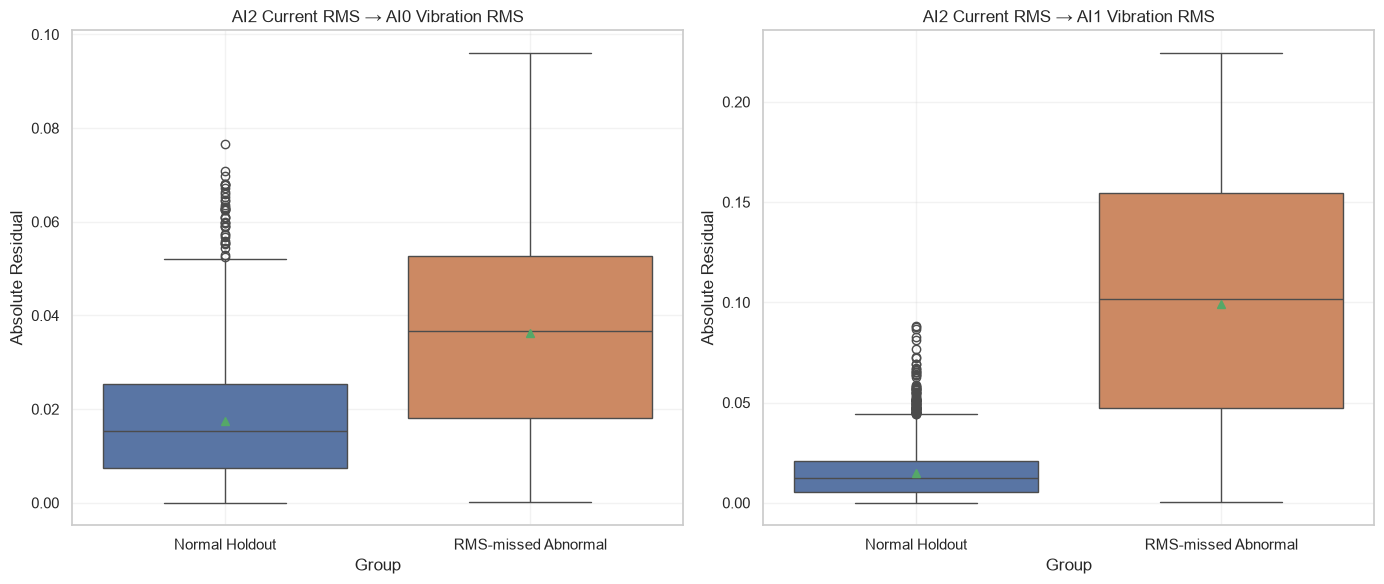

c:\Users\astra\Desktop\K_eng\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\astra\Desktop\K_eng\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


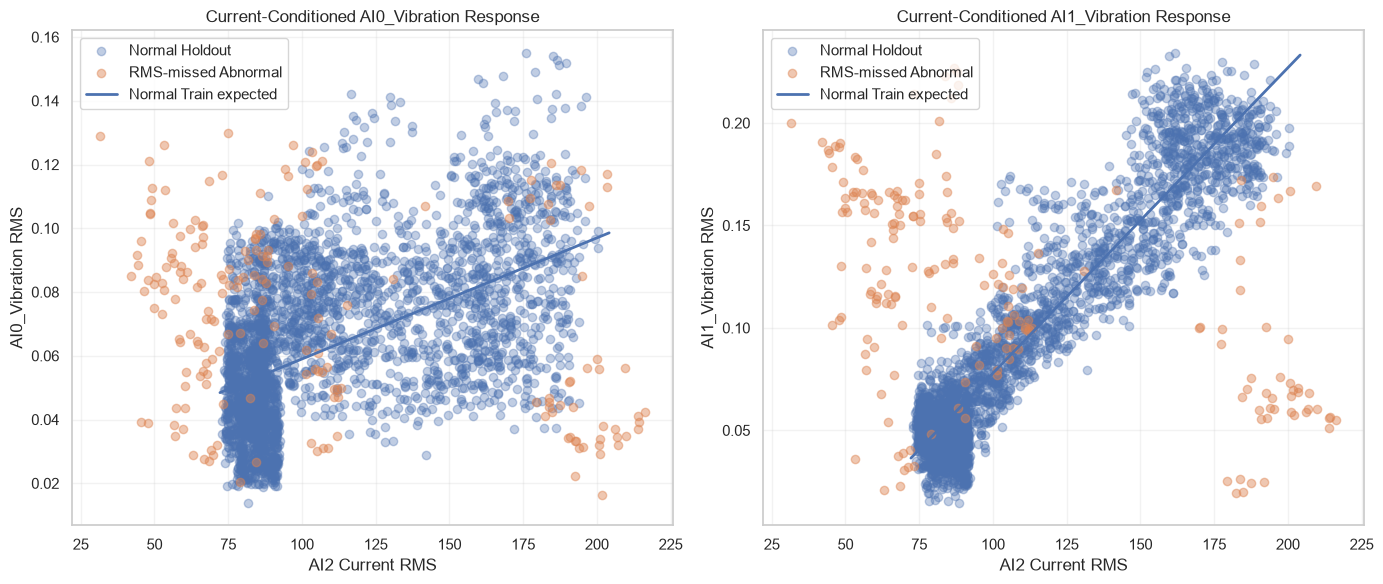


=== H1 Regression / Residual Statistics ===
      Pair               Group   Slope     R2  Mean_Abs_Residual  Std_Abs_Residual  Median_Abs_Residual     Q1     Q3
AI2 -> AI0        Normal Train  0.0004 0.3319             0.0163            0.0118               0.0144 0.0073 0.0226
AI2 -> AI0      Normal Holdout  0.0004 0.2883             0.0175            0.0125               0.0153 0.0074 0.0254
AI2 -> AI0 RMS-missed Abnormal -0.0002 0.0793             0.0363            0.0213               0.0367 0.0181 0.0527
AI2 -> AI1        Normal Train  0.0015 0.8842             0.0158            0.0125               0.0133 0.0061 0.0225
AI2 -> AI1      Normal Holdout  0.0015 0.8833             0.0150            0.0123               0.0122 0.0056 0.0210
AI2 -> AI1 RMS-missed Abnormal -0.0004 0.2082             0.0994            0.0614               0.1017 0.0473 0.1548


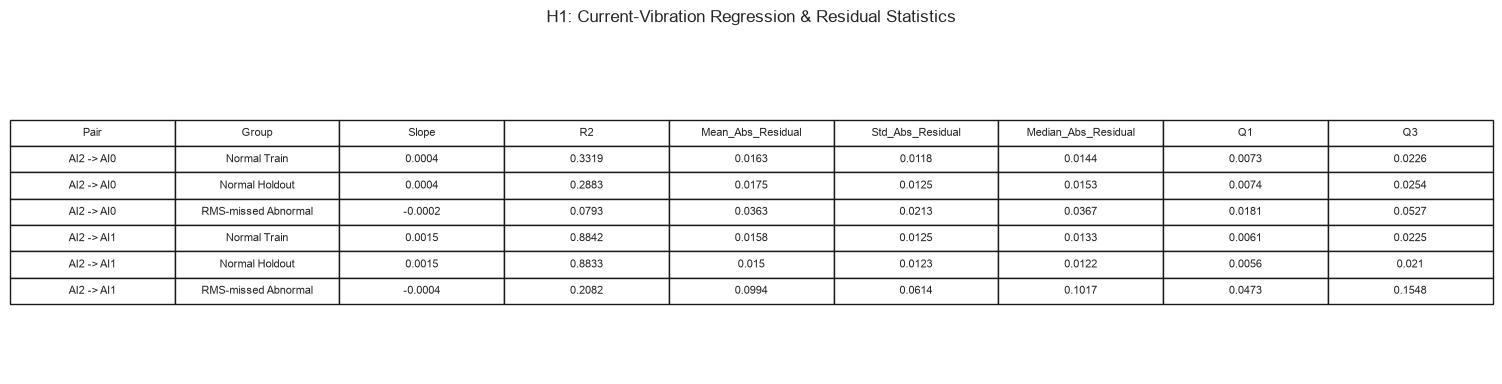


Saved to : c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_EDA_Sensor4\results


In [3]:
# H1: 정상 Train의 AI2 Current RMS → AI0/AI1 Vibration RMS 관계를 학습한다.
# 공식 preprocessed_data와 기존 segment를 사용하며 10-sample 완전 RMS window만 평가한다.
# Normal Holdout과 RMS-missed Abnormal의 정상모델 잔차를 비교해 관계 이탈을 확인한다.
# Abnormal 전용 회귀는 slope/R²의 기술적 비교에만 사용하고 이상판정에는 사용하지 않는다.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

SIGNALS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW, TEST_EVERY = 10, 5

def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
OUT = ROOT / "KAMP/05_EDA/05_EDA_Sensor4/results"
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. 공식 데이터 + RMS + 기존 방식 Train/Holdout split
# ------------------------------------------------------------
data = pd.read_csv(DATA_PATH)
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])

for c in SIGNALS:
    data[f"{c}_RMS"] = data.groupby("segment_id", sort=False)[c].transform(
        lambda x: np.sqrt(x.pow(2).rolling(WINDOW, min_periods=WINDOW).mean())
    )

# 각 source 내부 segment 등장순서를 기준으로 5개마다 1개 Holdout
data["seg_order"] = data.groupby("source")["segment_id"].transform(
    lambda x: pd.factorize(x, sort=False)[0]
)
data["split"] = np.where(data["seg_order"] % TEST_EVERY == TEST_EVERY // 2, "holdout", "train")

normal = data[data.source == "normal"].copy()
abnormal = data[data.source == "abnormal"].copy()
RMS_COLS = [f"{c}_RMS" for c in SIGNALS]

# ------------------------------------------------------------
# 2. RMS-IQR Baseline → RMS-missed Abnormal
# ------------------------------------------------------------
q1, q3 = normal[RMS_COLS].quantile(.25), normal[RMS_COLS].quantile(.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

for df in [normal, abnormal]:
    df["RMS_evaluable"] = df[RMS_COLS].notna().all(axis=1)
    flag = ((df[RMS_COLS] < lo) | (df[RMS_COLS] > hi)).any(axis=1)
    df["RMS_Detected"] = df.RMS_evaluable & flag
    df["RMS_Missed"] = df.RMS_evaluable & ~df.RMS_Detected

normal_train = normal[(normal.split == "train") & normal.RMS_evaluable].copy()
normal_holdout = normal[(normal.split == "holdout") & normal.RMS_evaluable].copy()
missed = abnormal[abnormal.RMS_Missed].copy()

print("=====================================================================")
print("                 [H1 Current-Vibration Residual Analysis]")
print("=====================================================================")
print(f"Normal Train           : {len(normal_train):,}")
print(f"Normal Holdout         : {len(normal_holdout):,}")
print(f"Abnormal RMS evaluable : {abnormal.RMS_evaluable.sum():,}")
print(f"Abnormal RMS detected  : {abnormal.RMS_Detected.sum():,}")
print(f"Abnormal RMS missed    : {len(missed):,}")

# ------------------------------------------------------------
# 3. Normal Train 회귀모델 + 정상모델 기준 residual
# ------------------------------------------------------------
models, rows = {}, []

for vib in ["AI0_Vibration", "AI1_Vibration"]:
    xcol, ycol = "AI2_Current_RMS", f"{vib}_RMS"
    model = LinearRegression().fit(normal_train[[xcol]], normal_train[ycol])
    models[vib] = model

    train_pred = model.predict(normal_train[[xcol]])
    hold_pred = model.predict(normal_holdout[[xcol]])
    miss_pred = model.predict(missed[[xcol]])

    normal_train[f"{vib}_Residual"] = normal_train[ycol] - train_pred
    normal_holdout[f"{vib}_Residual"] = normal_holdout[ycol] - hold_pred
    missed[f"{vib}_Residual"] = missed[ycol] - miss_pred

    # Abnormal 자체 slope/R²는 기술적 비교용으로만 계산
    ab_model = LinearRegression().fit(missed[[xcol]], missed[ycol])

    for group, df, fit_model in [
        ("Normal Train", normal_train, model),
        ("Normal Holdout", normal_holdout, model),
        ("RMS-missed Abnormal", missed, ab_model)
    ]:
        resid = df[f"{vib}_Residual"].abs()
        X, y = df[[xcol]], df[ycol]

        rows.append({
            "Pair": f"AI2 -> {vib[:3]}",
            "Group": group,
            "Slope": fit_model.coef_[0],
            "R2": r2_score(y, fit_model.predict(X)) if group != "Normal Holdout" else r2_score(y, model.predict(X)),
            "Mean_Abs_Residual": resid.mean(),
            "Std_Abs_Residual": resid.std(),
            "Median_Abs_Residual": resid.median(),
            "Q1": resid.quantile(.25),
            "Q3": resid.quantile(.75)
        })

stats_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 4. Residual Boxplot : Holdout vs RMS-missed Abnormal
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, vib, title in zip(
    axes,
    ["AI0_Vibration", "AI1_Vibration"],
    ["AI2 Current RMS → AI0 Vibration RMS", "AI2 Current RMS → AI1 Vibration RMS"]
):
    plot_df = pd.concat([
        pd.DataFrame({
            "Absolute Residual": normal_holdout[f"{vib}_Residual"].abs(),
            "Group": "Normal Holdout"
        }),
        pd.DataFrame({
            "Absolute Residual": missed[f"{vib}_Residual"].abs(),
            "Group": "RMS-missed Abnormal"
        })
    ], ignore_index=True)

    sns.boxplot(data=plot_df, x="Group", y="Absolute Residual", hue="Group",
                ax=ax, showmeans=True, legend=False)
    ax.set_title(title)
    ax.grid(alpha=.25)

plt.tight_layout()
plt.savefig(OUT / "h1_residual_boxplot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 5. Current RMS × Vibration RMS 정상관계 시각화
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, vib in zip(axes, ["AI0_Vibration", "AI1_Vibration"]):
    xcol, ycol = "AI2_Current_RMS", f"{vib}_RMS"
    model = models[vib]
    x = np.linspace(normal_train[xcol].min(), normal_train[xcol].max(), 200).reshape(-1, 1)

    ax.scatter(normal_holdout[xcol], normal_holdout[ycol], alpha=.35, label="Normal Holdout")
    ax.scatter(missed[xcol], missed[ycol], alpha=.45, label="RMS-missed Abnormal")
    ax.plot(x[:,0], model.predict(x), linewidth=2, label="Normal Train expected")

    ax.set_xlabel("AI2 Current RMS")
    ax.set_ylabel(f"{vib} RMS")
    ax.set_title(f"Current-Conditioned {vib} Response")
    ax.legend(); ax.grid(alpha=.25)

plt.tight_layout()
plt.savefig(OUT / "h1_current_vibration_relation.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 6. 통계표
# ------------------------------------------------------------
print("\n=== H1 Regression / Residual Statistics ===")
print(stats_df.round(4).to_string(index=False))

stats_df.to_csv(OUT / "h1_residual_statistics.csv", index=False)

fig, ax = plt.subplots(figsize=(15, 4))
ax.axis("off")
table = ax.table(
    cellText=stats_df.round(4).values,
    colLabels=stats_df.columns,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.5)
plt.title("H1: Current-Vibration Regression & Residual Statistics", pad=20)
plt.tight_layout()
plt.savefig(OUT / "h1_residual_statistics_table.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved to : {OUT}")

In [6]:
# 공식 preprocessed_data.csv에서 continuity segment별 Sensor Feature Table을 생성한다.
# 기존 segment_id를 그대로 사용하고 10-sample 완전 Rolling RMS만 Feature 계산에 사용한다.
# H1 AI2→AI1 정상관계는 Normal Train에서만 학습해 absolute residual을 계산한다.
# 이 Table은 Sensor-level EDA 요약이며 최종 FE 통합표는 07_Feature_Engineering에서 별도로 만든다.

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

SIGNALS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW, TEST_EVERY, EPS = 10, 5, 1e-6

def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
OUT = ROOT / "KAMP/05_EDA/05_EDA_Sensor4/results"
OUT.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("                 [Sensor-level Segment Feature Table]")
print("=" * 90)

# ------------------------------------------------------------
# 1. 공식 전처리 데이터 + RMS + Train/Holdout
# ------------------------------------------------------------
data = pd.read_csv(DATA_PATH)
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])

data["seg_order"] = data.groupby("source")["segment_id"].transform(
    lambda x: pd.factorize(x, sort=False)[0]
)
data["split"] = np.where(data["seg_order"] % TEST_EVERY == TEST_EVERY // 2, "holdout", "train")

for c in SIGNALS:
    data[f"{c}_RMS"] = data.groupby("segment_id", sort=False)[c].transform(
        lambda x: np.sqrt(x.pow(2).rolling(WINDOW, min_periods=WINDOW).mean())
    )

RMS_COLS = [f"{c}_RMS" for c in SIGNALS]
data["RMS_evaluable"] = data[RMS_COLS].notna().all(axis=1)

# ------------------------------------------------------------
# 2. H1 정상모델: Normal Train AI2 RMS → AI1 RMS
# ------------------------------------------------------------
normal_train = data[
    (data.source == "normal") &
    (data.split == "train") &
    data.RMS_evaluable
].copy()

lr_ai1 = LinearRegression().fit(
    normal_train[["AI2_Current_RMS"]],
    normal_train["AI1_Vibration_RMS"]
)

print(f"Normal Train RMS rows : {len(normal_train):,}")
print(f"H1 slope              : {lr_ai1.coef_[0]:.6f}")
print(f"H1 intercept          : {lr_ai1.intercept_:.6f}")
print(f"H1 R²                 : {lr_ai1.score(normal_train[['AI2_Current_RMS']], normal_train['AI1_Vibration_RMS']):.4f}")

# ------------------------------------------------------------
# 3. Segment-level Feature
# ------------------------------------------------------------
def segment_features(df):
    rows = []

    for seg_id, g in df.groupby("segment_id", sort=False):
        valid = g[g.RMS_evaluable].copy()
        feat = {
            "segment_id": seg_id,
            "source": g.source.iloc[0],
            "split": g.split.iloc[0],
            "label": int(g.source.iloc[0] == "abnormal"),
            "data_count": len(g),
            "rms_valid_count": len(valid),
            "rms_evaluable": len(valid) > 0,
            "duration_sec": g.elapsed_sec.iloc[-1] - g.elapsed_sec.iloc[0]
        }

        if len(valid):
            nd = (
                valid["AI0_Vibration_RMS"] - valid["AI1_Vibration_RMS"]
            ) / (
                valid["AI0_Vibration_RMS"] + valid["AI1_Vibration_RMS"] + EPS
            )

            pred = lr_ai1.predict(valid[["AI2_Current_RMS"]])
            abs_res = np.abs(valid["AI1_Vibration_RMS"].to_numpy() - pred)

            feat.update({
                "ai0_rms_mean": valid["AI0_Vibration_RMS"].mean(),
                "ai0_rms_max": valid["AI0_Vibration_RMS"].max(),
                "ai1_rms_mean": valid["AI1_Vibration_RMS"].mean(),
                "ai1_rms_max": valid["AI1_Vibration_RMS"].max(),
                "ai2_rms_mean": valid["AI2_Current_RMS"].mean(),
                "ai2_rms_max": valid["AI2_Current_RMS"].max(),
                "nd_mean": nd.mean(),
                "nd_max": nd.max(),
                "ai1_abs_residual_mean": abs_res.mean(),
                "ai1_abs_residual_max": abs_res.max()
            })
        else:
            for c in [
                "ai0_rms_mean", "ai0_rms_max", "ai1_rms_mean", "ai1_rms_max",
                "ai2_rms_mean", "ai2_rms_max", "nd_mean", "nd_max",
                "ai1_abs_residual_mean", "ai1_abs_residual_max"
            ]:
                feat[c] = np.nan

        rows.append(feat)

    return pd.DataFrame(rows)

feature_table = segment_features(data)

# ------------------------------------------------------------
# 4. 저장 / 출력
# ------------------------------------------------------------
SAVE_PATH = OUT / "sensor_segment_feature_table.csv"
feature_table.to_csv(SAVE_PATH, index=False)

print("\n=== Segment Summary ===")
print(feature_table.groupby("source").agg(
    segments=("segment_id", "count"),
    rms_evaluable=("rms_evaluable", "sum"),
    median_rows=("data_count", "median"),
    median_duration=("duration_sec", "median")
).round(3).to_string())

print("\n=== Feature Table Preview ===")
pd.set_option("display.max_columns", None)
print(feature_table.head(10).round(4).to_string(index=False))

print("\n" + "=" * 90)
print(f"Total segments : {len(feature_table):,}")
print(f"Saved to       : {SAVE_PATH}")
print("=" * 90)

                 [Sensor-level Segment Feature Table]
Normal Train RMS rows : 11,832
H1 slope              : 0.001491
H1 intercept          : -0.071177
H1 R²                 : 0.8842

=== Segment Summary ===
          segments  rms_evaluable  median_rows  median_duration
source                                                         
abnormal        21             17         28.0              2.7
normal         599            530         37.0              3.6

=== Feature Table Preview ===
segment_id source   split  label  data_count  rms_valid_count  rms_evaluable  duration_sec  ai0_rms_mean  ai0_rms_max  ai1_rms_mean  ai1_rms_max  ai2_rms_mean  ai2_rms_max  nd_mean  nd_max  ai1_abs_residual_mean  ai1_abs_residual_max
     N0000 normal   train      0          41               32           True           4.0        0.0691       0.0929        0.1598       0.1800      148.8842     163.1120  -0.4001 -0.1856                 0.0139                0.0342
     N0001 normal   train      0     

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. 폰트 및 시각화 스타일 설정 (기존 선호하시는 원본 색상 적용)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

print("===================================================================================")
print("                [AI0 및 AI1-AI2 관계 이상특성 분석 및 시각화 시작]")
print("===================================================================================") 

# 2. 데이터 로드
normal_df = pd.read_csv('press_data_normal.csv')
outlier_df = pd.read_csv('outlier_data.csv')

# 3. 타임스탬프 무결성 검증 및 세그먼트 분리 전처리 함수
def preprocess_and_segment(df, time_threshold=0.15):
    df = df.copy()
    df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
    df = df.sort_values('TimeStamp').reset_index(drop=True)
    df['time_diff'] = df['TimeStamp'].diff().dt.total_seconds().fillna(0)
    df['segment_id'] = (df['time_diff'] > time_threshold).cumsum()
    return df

normal_proc = preprocess_and_segment(normal_df)
outlier_proc = preprocess_and_segment(outlier_df)

cols = ['AI0_Vibration', 'AI1_Vibration', 'AI2_Current']
window_size = 10

# 4. Rolling RMS 계산 함수
def calculate_segment_rms(df, cols, window=10):
    rms_list = []
    for seg_id, group in df.groupby('segment_id'):
        g_rms = group[cols].pow(2).rolling(window=window, min_periods=1).mean().pow(0.5)
        g_rms['segment_id'] = seg_id
        g_rms['TimeStamp'] = group['TimeStamp']
        g_rms['Equipment_state'] = group['Equipment_state']
        for c in cols:
            g_rms[f'{c}_Raw'] = group[c].values
        rms_list.append(g_rms)
    return pd.concat(rms_list).sort_index()

normal_rms = calculate_segment_rms(normal_proc, cols, window=window_size)
outlier_rms = calculate_segment_rms(outlier_proc, cols, window=window_size)

# 5. IQR Thresholds 산출 및 RMS 검출/미검출(RMS_Detected / RMS_Missed) 분리
thresholds = {}
for col in cols:
    q1 = normal_rms[col].quantile(0.25)
    q3 = normal_rms[col].quantile(0.75)
    iqr = q3 - q1
    thresholds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

detections = {}
for col in cols:
    lower, upper = thresholds[col]
    detections[col] = (outlier_rms[col] < lower) | (outlier_rms[col] > upper)

combined_detected = detections['AI0_Vibration'] | detections['AI1_Vibration'] | detections['AI2_Current']
outlier_rms['RMS_Detected'] = combined_detected
undetected_rms = outlier_rms[~outlier_rms['RMS_Detected']].copy()

print(f"-> 전체 이상 행 수: {len(outlier_rms)}개 | RMS 검출: {combined_detected.sum()}개 | RMS 미검출(Missed): {len(undetected_rms)}개")

# ===================================================================================
# [주제 1] AI0 자체 이상특성 분석 및 시각화
# ===================================================================================
print("\n-> [생성 중] AI0 자체 이상특성 분석 시각화 ('ai0_individual_analysis.png')...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: AI0 밀도 분포(KDE) 비교
sns.kdeplot(normal_rms['AI0_Vibration'], label='Normal', ax=axes[0], color='blue', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(outlier_rms['AI0_Vibration'], label='Outlier (Total)', ax=axes[0], color='red', fill=True, alpha=0.3, linewidth=2)
axes[0].set_title('AI0 Vibration RMS Distribution (Normal vs Total Outlier)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('AI0 Vibration RMS', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=11)

# Right: 그룹별 비교 박스플롯 (배열 정돈 및 원본 색상 적용)
outlier_rms_copy = outlier_rms.copy()
outlier_rms_copy['Group'] = np.where(outlier_rms_copy['RMS_Detected'], 'RMS_Detected', 'RMS_Missed')
plot_box_data = pd.concat([
    pd.DataFrame({'AI0_Vibration': normal_rms['AI0_Vibration'], 'Group': 'Normal'}),
    pd.DataFrame({'AI0_Vibration': outlier_rms_copy['AI0_Vibration'], 'Group': outlier_rms_copy['Group']})
])
plot_box_data['Group'] = pd.Categorical(plot_box_data['Group'], categories=['Normal', 'RMS_Detected', 'RMS_Missed'], ordered=True)

sns.boxplot(data=plot_box_data, x='Group', y='AI0_Vibration', hue='Group', ax=axes[1], 
            palette=['blue', 'orange', 'red'], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
            boxprops=dict(alpha=0.85), width=0.5)

axes[1].set_title('AI0 RMS Comparison across Groups', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Classification Group', fontsize=11)
axes[1].set_ylabel('AI0 Vibration RMS', fontsize=11)
if axes[1].get_legend():
    axes[1].get_legend().remove()

plt.tight_layout()
plt.savefig('ai0_individual_analysis.png', dpi=300)
plt.close()


# ===================================================================================
# [주제 2] AI1 - AI2 관계 이상특성 (회귀 잔차) 분석 및 시각화
# ===================================================================================
print("-> [생성 중] AI1-AI2 관계 잔차 분석 시각화 ('ai1_ai2_relationship_analysis.png')...")

# Normal 기준 AI2(Current) -> AI1(Vibration) 선형회귀 모델 학습
lr_ai1_ai2 = LinearRegression().fit(normal_rms[['AI2_Current']], normal_rms['AI1_Vibration'])
normal_ai1_res = np.abs(normal_rms['AI1_Vibration'] - lr_ai1_ai2.predict(normal_rms[['AI2_Current']]))
undetected_ai1_res = np.abs(undetected_rms['AI1_Vibration'] - lr_ai1_ai2.predict(undetected_rms[['AI2_Current']]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: 산점도 (Normal vs RMS-Missed Outlier)
axes[0].scatter(normal_rms['AI2_Current'], normal_rms['AI1_Vibration'], alpha=0.3, color='blue', label='Normal', s=12)
axes[0].scatter(undetected_rms['AI2_Current'], undetected_rms['AI1_Vibration'], alpha=0.6, color='orange', label='RMS-Missed Outlier', s=25, edgecolor='black', linewidth=0.5)
axes[0].set_title('AI2 (Current) vs AI1 (Vibration) Relationship', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('AI2 Current RMS', fontsize=11)
axes[0].set_ylabel('AI1 Vibration RMS', fontsize=11)
axes[0].legend(fontsize=11)

# Right: 절대 잔차(Absolute Residual) 박스플롯 비교
res_data = pd.DataFrame({
    'Absolute Residual': np.concatenate([normal_ai1_res, undetected_ai1_res]),
    'Group': ['Normal']*len(normal_ai1_res) + ['RMS-Missed']*len(undetected_ai1_res)
})
res_data['Group'] = pd.Categorical(res_data['Group'], categories=['Normal', 'RMS-Missed'], ordered=True)

sns.boxplot(data=res_data, x='Group', y='Absolute Residual', hue='Group', ax=axes[1], 
            palette=['blue', 'orange'], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
            boxprops=dict(alpha=0.85), width=0.4)

axes[1].set_title('AI2 -> AI1 Regression Absolute Residual', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Classification Group', fontsize=11)
axes[1].set_ylabel('Absolute Residual Value', fontsize=11)
if axes[1].get_legend():
    axes[1].get_legend().remove()

plt.tight_layout()
plt.savefig('ai1_ai2_relationship_analysis.png', dpi=300)
plt.close()

print("===================================================================================")
print("-> [완료] 시각화 이미지 생성 완료!")
print("===================================================================================")

                 [Sensor-level Segment Feature Table]
Normal Train RMS rows : 11,832
H1 slope              : 0.001491
H1 intercept          : -0.071177
H1 R²                 : 0.8842

=== Segment Summary ===
          segments  rms_evaluable  median_rows  median_duration
source                                                         
abnormal        21             17         28.0              2.7
normal         599            530         37.0              3.6

=== Feature Table Preview ===
segment_id source   split  label  data_count  rms_valid_count  rms_evaluable  duration_sec  ai0_rms_mean  ai0_rms_max  ai1_rms_mean  ai1_rms_max  ai2_rms_mean  ai2_rms_max  nd_mean  nd_max  ai1_abs_residual_mean  ai1_abs_residual_max
     N0000 normal   train      0          41               32           True           4.0        0.0691       0.0929        0.1598       0.1800      148.8842     163.1120  -0.4001 -0.1856                 0.0139                0.0342
     N0001 normal   train      0     

In [8]:
# 공식 전처리 데이터에서 continuity segment별 Sensor Feature Table을 만든다.
# 기존 segment_id를 그대로 사용하고 완전한 10-sample RMS만 Feature 계산에 사용한다.
# H1 AI2→AI1 정상관계는 Normal Train에서만 학습해 residual Feature를 계산한다.
# 최종 Feature Table이 아니라 Sensor-level EDA용 Segment 요약 Table이다.

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

SIGNALS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
WINDOW, TEST_EVERY, EPS = 10, 5, 1e-6

def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
OUT = ROOT / "KAMP/05_EDA/05_EDA_Sensor4/results"
OUT.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("                 [Sensor-level Segment Feature Table]")
print("=" * 90)

# 1. 공식 데이터 + Train/Holdout + 완전 RMS
data = pd.read_csv(DATA_PATH)
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])
data["seg_order"] = data.groupby("source")["segment_id"].transform(lambda x: pd.factorize(x, sort=False)[0])
data["split"] = np.where(data["seg_order"] % TEST_EVERY == TEST_EVERY // 2, "holdout", "train")

for c in SIGNALS:
    data[f"{c}_RMS"] = data.groupby("segment_id", sort=False)[c].transform(
        lambda x: np.sqrt(x.pow(2).rolling(WINDOW, min_periods=WINDOW).mean())
    )

RMS_COLS = [f"{c}_RMS" for c in SIGNALS]
data["RMS_evaluable"] = data[RMS_COLS].notna().all(axis=1)

# 2. Normal Train에서 H1 AI2 RMS → AI1 RMS 정상관계 학습
normal_train = data[
    (data.source == "normal") &
    (data.split == "train") &
    data.RMS_evaluable
].copy()

lr_ai1 = LinearRegression().fit(
    normal_train[["AI2_Current_RMS"]],
    normal_train["AI1_Vibration_RMS"]
)

print(f"Normal Train RMS rows : {len(normal_train):,}")
print(f"H1 slope              : {lr_ai1.coef_[0]:.6f}")
print(f"H1 intercept          : {lr_ai1.intercept_:.6f}")
print(f"H1 R²                 : {lr_ai1.score(normal_train[['AI2_Current_RMS']], normal_train['AI1_Vibration_RMS']):.4f}")

# 3. Continuity Segment별 Feature 집계
def make_segment_features(df):
    rows = []

    for seg_id, g in df.groupby("segment_id", sort=False):
        valid = g[g.RMS_evaluable].copy()

        feat = {
            "segment_id": seg_id,
            "source": g.source.iloc[0],
            "split": g.split.iloc[0],
            "label": int(g.source.iloc[0] == "abnormal"),
            "data_count": len(g),
            "rms_valid_count": len(valid),
            "rms_evaluable": len(valid) > 0,
            "duration_sec": g.elapsed_sec.iloc[-1] - g.elapsed_sec.iloc[0]
        }

        if len(valid):
            nd = (
                valid["AI0_Vibration_RMS"] - valid["AI1_Vibration_RMS"]
            ) / (
                valid["AI0_Vibration_RMS"] + valid["AI1_Vibration_RMS"] + EPS
            )

            pred = lr_ai1.predict(valid[["AI2_Current_RMS"]])
            abs_res = np.abs(valid["AI1_Vibration_RMS"].to_numpy() - pred)

            feat.update({
                "ai0_rms_mean": valid["AI0_Vibration_RMS"].mean(),
                "ai0_rms_max": valid["AI0_Vibration_RMS"].max(),
                "ai1_rms_mean": valid["AI1_Vibration_RMS"].mean(),
                "ai1_rms_max": valid["AI1_Vibration_RMS"].max(),
                "ai2_rms_mean": valid["AI2_Current_RMS"].mean(),
                "ai2_rms_max": valid["AI2_Current_RMS"].max(),
                "nd_mean": nd.mean(),
                "nd_max": nd.max(),
                "ai1_abs_residual_mean": abs_res.mean(),
                "ai1_abs_residual_max": abs_res.max()
            })
        else:
            for c in [
                "ai0_rms_mean", "ai0_rms_max", "ai1_rms_mean", "ai1_rms_max",
                "ai2_rms_mean", "ai2_rms_max", "nd_mean", "nd_max",
                "ai1_abs_residual_mean", "ai1_abs_residual_max"
            ]:
                feat[c] = np.nan

        rows.append(feat)

    return pd.DataFrame(rows)

feature_table = make_segment_features(data)

# 4. 저장 / 확인
SAVE_PATH = OUT / "sensor_segment_feature_table.csv"
feature_table.to_csv(SAVE_PATH, index=False)

print("\n=== Segment Summary ===")
print(feature_table.groupby("source").agg(
    segments=("segment_id", "count"),
    rms_evaluable=("rms_evaluable", "sum"),
    median_rows=("data_count", "median"),
    median_duration=("duration_sec", "median")
).round(3).to_string())

print("\n=== Feature Table Preview ===")
pd.set_option("display.max_columns", None)
print(feature_table.head(10).round(4).to_string(index=False))

print("\n" + "=" * 90)
print(f"Total segments : {len(feature_table):,}")
print(f"Saved to       : {SAVE_PATH}")
print("=" * 90)

                 [Sensor-level Segment Feature Table]


Normal Train RMS rows : 11,832
H1 slope              : 0.001491
H1 intercept          : -0.071177
H1 R²                 : 0.8842

=== Segment Summary ===
          segments  rms_evaluable  median_rows  median_duration
source                                                         
abnormal        21             17         28.0              2.7
normal         599            530         37.0              3.6

=== Feature Table Preview ===
segment_id source   split  label  data_count  rms_valid_count  rms_evaluable  duration_sec  ai0_rms_mean  ai0_rms_max  ai1_rms_mean  ai1_rms_max  ai2_rms_mean  ai2_rms_max  nd_mean  nd_max  ai1_abs_residual_mean  ai1_abs_residual_max
     N0000 normal   train      0          41               32           True           4.0        0.0691       0.0929        0.1598       0.1800      148.8842     163.1120  -0.4001 -0.1856                 0.0139                0.0342
     N0001 normal   train      0          37               28           True           3.6 